## 1. Comprendre les types de classification

La classification est une tâche de machine learning qui consiste à attribuer une étiquette de catégorie à de nouvelles observations. Il existe différents types de classification, chacun adapté à des problèmes spécifiques.

### Classification Binaire

La classification binaire est le type de classification le plus simple, où le modèle doit classer les données en deux catégories mutuellement exclusives. Il s'agit de prédire l'une des deux classes possibles.

**Exemple :**
*   **Détection de spam :** Un e-mail est soit un spam, soit non.
*   **Diagnostic médical :** Un patient est soit atteint d'une maladie, soit non.
*   **Prédiction de churn :** Un client va soit résilier son abonnement, soit non.

### Classification Multiclasse

La classification multiclasse est une tâche où le modèle doit classer les données dans l'une des trois catégories ou plus, mais les catégories sont mutuellement exclusives. Chaque instance appartient à une et une seule classe.

**Exemple :**
*   **Reconnaissance de chiffres manuscrits :** Un chiffre (0, 1, 2, ..., 9) est classé comme l'un des dix chiffres possibles.
*   **Classification d'images :** Une image contient un chat, un chien ou un oiseau.
*   **Analyse de sentiment :** Un texte est classé comme positif, négatif ou neutre.

### Classification Multi-étiquettes

La classification multi-étiquettes est une tâche où le modèle peut attribuer zéro, une ou plusieurs étiquettes à une seule instance. Les catégories ne sont pas mutuellement exclusives, ce qui signifie qu'une instance peut appartenir à plusieurs classes simultanément.

**Exemple :**
*   **Tagging de photos :** Une photo peut contenir plusieurs objets (par exemple, 'plage', 'personnes', 'coucher de soleil').
*   **Catégorisation de documents :** Un article de presse peut appartenir à plusieurs catégories (par exemple, 'politique', 'économie', 'international').
*   **Diagnostic médical (avancé) :** Un patient peut présenter plusieurs symptômes ou maladies simultanément.

## 2. Configuration de l'environnement Python et création du jeu de données

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import make_circles

### Création d'un ensemble de données pour la classification binaire

In [2]:
samples = 1000
X, y = make_circles(samples,
                    noise = 0.03,
                    random_state = 42)

print('X (premières 5 lignes) :\n', X[:5])
print('\n')
print('y (premières 5 lignes) :\n', y[:5])

X (premières 5 lignes) :
 [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]


y (premières 5 lignes) :
 [1 1 1 1 0]


### Visualisation de l'ensemble de données

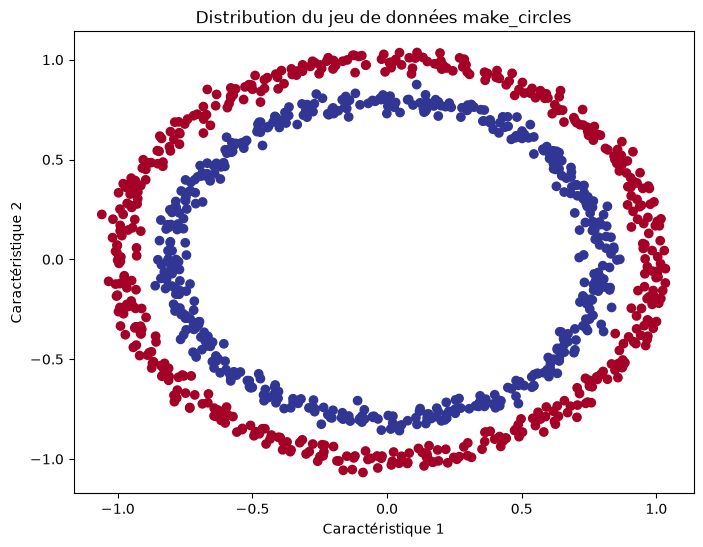

In [3]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)
plt.title('Distribution du jeu de données make_circles')
plt.xlabel('Caractéristique 1')
plt.ylabel('Caractéristique 2')
plt.show()

## 3. Construire un modèle de réseau neuronal de base

In [4]:
# Créer un modèle séquentiel avec une couche dense
model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation='sigmoid') # Utilisation de sigmoid pour la classification binaire
])

# Compiler le modèle
model_1.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.SGD(), # Stochastic Gradient Descent
                metrics=['accuracy'])

# Entraîner le modèle
history_1 = model_1.fit(X, y, epochs=100, verbose=0) # verbose=0 pour ne pas afficher la progression de l'entraînement

# Évaluer le modèle
loss, accuracy = model_1.evaluate(X, y)
print(f"Précision du modèle sur les données d'entraînement : {accuracy*100:.2f}%")

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 874us/step - accuracy: 0.5000 - loss: 0.6932
Précision du modèle sur les données d'entraînement : 50.00%


## 4. Améliorer le modèle

In [5]:
# Créer un modèle séquentiel avec plus de couches et de neurones
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu'), # Ajout d'une couche cachée avec activation ReLU
    tf.keras.layers.Dense(10, activation='relu'), # Ajout d'une deuxième couche cachée
    tf.keras.layers.Dense(1, activation='sigmoid')  # Couche de sortie pour la classification binaire
])

# Compiler le modèle avec l'optimiseur Adam et plus d'epochs
model_2.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(), # Changement d'optimiseur à Adam
                metrics=['accuracy'])

# Entraîner le modèle avec plus d'epochs
history_2 = model_2.fit(X, y, epochs=200, verbose=0) # Augmentation du nombre d'epochs

# Évaluer le modèle amélioré
loss_2, accuracy_2 = model_2.evaluate(X, y)
print(f"Précision du modèle amélioré sur les données d'entraînement : {accuracy_2*100:.2f}%")

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 1.0000 - loss: 0.0051 
Précision du modèle amélioré sur les données d'entraînement : 100.00%


## 5. Visualiser la frontière de décision

In [6]:
# Créer une fonction pour visualiser la frontière de décision
def plot_decision_boundary(model, X, y):
    # Définir la plage de l'axe x et y
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    # Créer les prédictions (à plat) pour l'ensemble du maillage
    X_grid = np.c_[xx.ravel(), yy.ravel()]
    y_pred = model.predict(X_grid)

    # Appliquer un seuil de 0.5 pour les prédictions binaires
    y_pred_binary = (y_pred > 0.5).astype(int)

    # Remodeler les prédictions pour qu'elles correspondent à la grille
    y_pred_reshaped = y_pred_binary.reshape(xx.shape)

    # Tracer la frontière de décision
    plt.contourf(xx, yy, y_pred_reshaped, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.title('Frontière de décision du modèle')
    plt.xlabel('Caractéristique 1')
    plt.ylabel('Caractéristique 2')
    plt.show()

### Visualisation de la frontière de décision pour le modèle amélioré (model_2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 496us/step


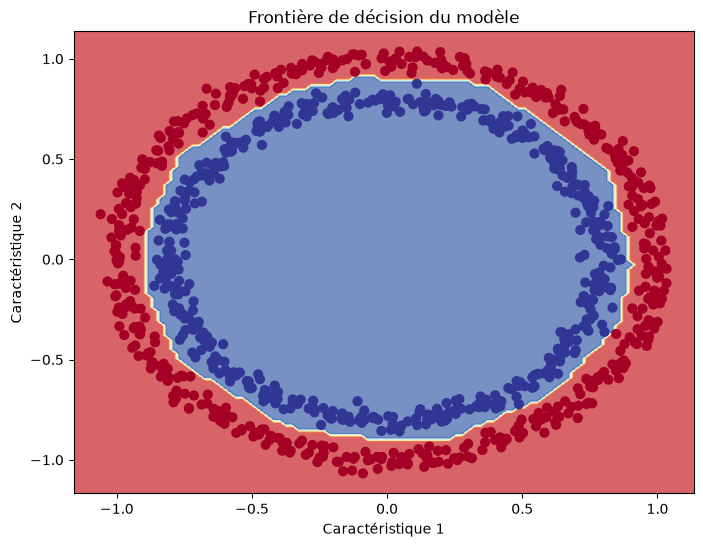

In [7]:
plt.figure(figsize=(8, 6))
plot_decision_boundary(model_2, X, y)

## 6. Incorporer des fonctions d'activation

Nous avons déjà utilisé la fonction d'activation Sigmoid pour la couche de sortie dans nos modèles précédents pour la classification binaire. Pour les couches cachées, nous avons utilisé ReLU (`tf.keras.layers.Dense(..., activation='relu')`).

Pour cette section, nous allons reconfirmer l'utilisation de ces fonctions d'activation et montrer leur placement typique dans un réseau neuronal.

In [8]:
# Créer un modèle avec des fonctions d'activation ReLU pour les couches cachées et Sigmoid pour la couche de sortie
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu'), # Couche cachée avec ReLU
    tf.keras.layers.Dense(10, activation='relu'), # Deuxième couche cachée avec ReLU
    tf.keras.layers.Dense(1, activation='sigmoid')  # Couche de sortie avec Sigmoid pour la classification binaire
])

# Compiler le modèle
model_3.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=['accuracy'])

# Entraîner le modèle
history_3 = model_3.fit(X, y, epochs=200, verbose=0)

# Évaluer le modèle
loss_3, accuracy_3 = model_3.evaluate(X, y)
print(f"Précision du modèle avec fonctions d'activation spécifiques : {accuracy_3*100:.2f}%")

# Comparer avec le modèle précédent (model_2 était déjà un bon exemple de cela)
print(f"Précision du modèle amélioré précédent (model_2) : {accuracy_2*100:.2f}%")

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 1.0000 - loss: 0.0056 
Précision du modèle avec fonctions d'activation spécifiques : 100.00%
Précision du modèle amélioré précédent (model_2) : 100.00%


### Visualisation de la frontière de décision pour le nouveau modèle (model_3)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 497us/step


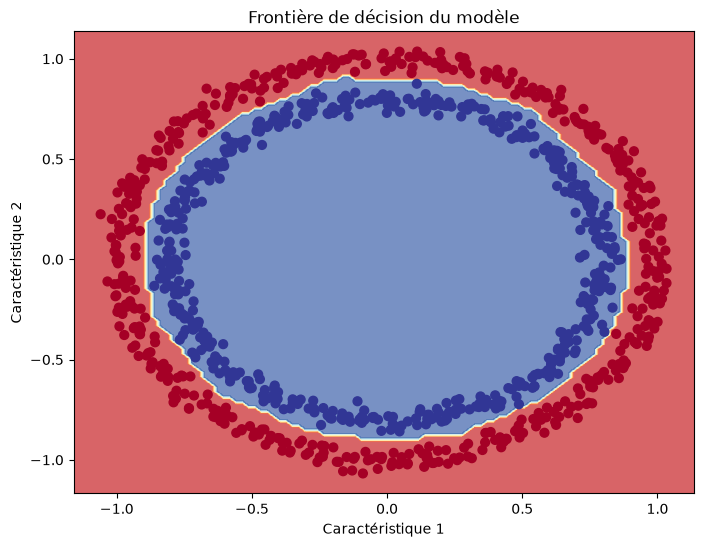

In [9]:
plt.figure(figsize=(8, 6))
plot_decision_boundary(model_3, X, y)

## 7. Diviser les données en ensembles d'entraînement et de test

In [10]:
from sklearn.model_selection import train_test_split

# Diviser les données en ensembles d'entraînement et de test (80% entraînement, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Taille de l'ensemble d'entraînement : {len(X_train)} échantillons")
print(f"Taille de l'ensemble de test : {len(X_test)} échantillons")

Taille de l'ensemble d'entraînement : 800 échantillons
Taille de l'ensemble de test : 200 échantillons


### Entraîner le modèle amélioré (model_3) sur l'ensemble d'entraînement et évaluer sur l'ensemble de test

In [11]:
# Créer un nouveau modèle (identique à model_3) pour l'entraînement sur les données divisées
model_split = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compiler le modèle
model_split.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                    optimizer=tf.keras.optimizers.Adam(),
                    metrics=['accuracy'])

# Entraîner le modèle sur l'ensemble d'entraînement
history_split = model_split.fit(X_train, y_train, epochs=200, verbose=0)

# Évaluer le modèle sur l'ensemble de test
loss_split, accuracy_split = model_split.evaluate(X_test, y_test)
print(f"Précision du modèle sur l'ensemble de test : {accuracy_split*100:.2f}%")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0202 
Précision du modèle sur l'ensemble de test : 100.00%


## 8. Évaluer et visualiser les performances du modèle final

Nous avons déjà vérifié la précision sur l'ensemble de test, qui est de 100%. Maintenant, visualisons la frontière de décision pour les données d'entraînement et de test.

### Visualisation de la frontière de décision sur les données d'entraînement

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 495us/step


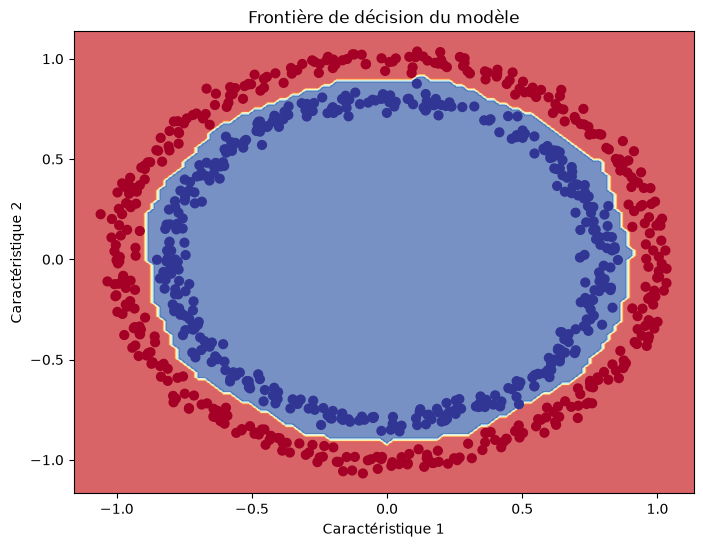

In [12]:
plt.figure(figsize=(8, 6))
plt.title('Frontière de décision sur les données d\'entraînement')
plot_decision_boundary(model_split, X_train, y_train)

### Visualisation de la frontière de décision sur les données de test

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 467us/step


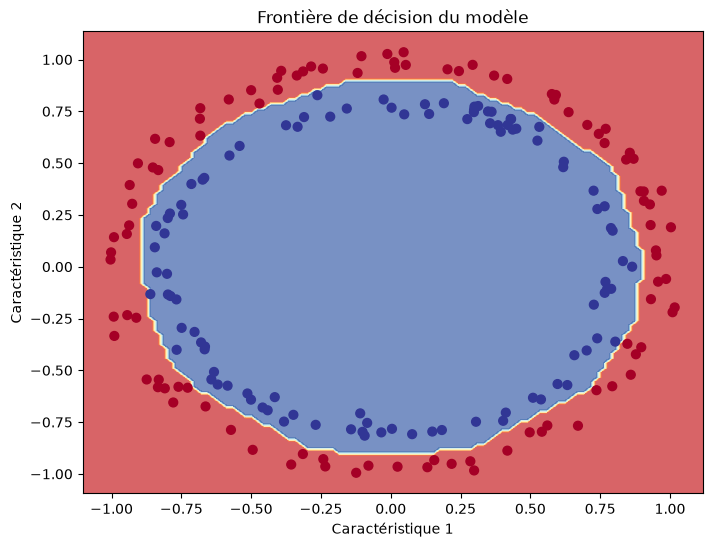

In [13]:
plt.figure(figsize=(8, 6))
plt.title('Frontière de décision sur les données de test')
plot_decision_boundary(model_split, X_test, y_test)

## 9. Résumer les points clés

Au cours de cet exercice, nous avons abordé plusieurs concepts fondamentaux de la classification en machine learning :

*   **Types de classification :** Nous avons distingué la classification binaire, multiclasse et multi-étiquettes, chacune adaptée à des problèmes spécifiques.
*   **Préparation des données :** L'importance de la création et de la visualisation d'un ensemble de données a été démontrée pour mieux comprendre la distribution des classes.
*   **Construction de modèles de réseaux neuronaux :** Nous avons débuté avec un modèle simple à une seule couche et avons observé ses limites sur un problème non linéaire.
*   **Amélioration du modèle :** En ajoutant plus de couches et de neurones, en augmentant le nombre d'époques d'entraînement et en utilisant un optimiseur plus avancé (Adam), nous avons considérablement amélioré la capacité du modèle à apprendre des motifs complexes.
*   **Fonctions d'activation :** Nous avons mis en évidence le rôle crucial des fonctions d'activation comme ReLU pour les couches cachées et Sigmoid pour la couche de sortie dans les problèmes de classification binaire.
*   **Visualisation des frontières de décision :** La fonction `plot_decision_boundary` s'est avérée essentielle pour comprendre visuellement comment le modèle sépare les classes et comment l'amélioration du modèle se traduit par une frontière de décision plus adaptée.
*   **Division des données (entraînement/test) :** L'évaluation d'un modèle sur des données de test non vues est fondamentale pour juger de sa capacité de généralisation et éviter le surapprentissage.

En résumé, la construction d'un modèle de classification efficace implique une compréhension des différents types de problèmes, une exploration minutieuse des données, une architecture de réseau neuronal appropriée, un réglage des hyperparamètres (comme les optimiseurs et le nombre d'époques) et une évaluation rigoureuse sur des ensembles de données séparés pour garantir une bonne généralisation. La visualisation est un outil puissant à chaque étape du processus pour diagnostiquer et améliorer les performances du modèle.